In [2]:
from fpdf import FPDF
from HARey.harey_main import HAReyMain
import random

In [3]:
pdf = FPDF(orientation="L", unit="in", format="A4")

In [4]:
harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey/HARey/cardbacks/tarot_round.png


In [5]:
bookmarks = 5
IDS = ['Ori', 'UMa', 'And', 'Gem']

In [5]:
harey.set_card_template('square')

for id in IDS:
    harey.set_flags({'CON_LINES':True, 'SAVE':True, 'SHOW':False})    
    harey.plot_card(id, BEST_AR=True, save_name=f'book/{id}_lines.png')
    harey.set_flags({'CON_LINES':False, 'SAVE':True, 'SHOW':False})
    harey.plot_card(id, BEST_AR=True, save_name=f'book/{id}_bare.png')

Using the square format, 2.00x2.75 in, using the template at /home/menegattig/Desktop/HARey/HARey/cardbacks/tarot_round.png


In [ ]:
# Create landscape PDF in inches
pdf = FPDF(orientation='L', unit='in', format='A4')

# Use page size from FPDF to avoid confusion
page_width = pdf.w    # 11.0 in (landscape)
page_height = pdf.h   # 8.5 in

box_width = 2
box_height = 6
boxes = 5
# Padding between and around boxes
pad_w = (page_width - boxes * box_width) / (boxes + 1)
pad_h = (page_height - box_height) / 2

# Font settings
font_size_pt = 10
pdf.set_font("Arial", size=font_size_pt)
# Text height in inches (1pt = 1/72 in)
text_height = font_size_pt / 72 + 0.01  # ~0.15 in
pdf.set_text_color(0, 255, 0)

pdf.set_auto_page_break(auto=False)

n_pages = (bookmarks + boxes - 1)//boxes

for i in range(n_pages):
    

    ids_page = [random.sample(IDS, 2) for _ in range(boxes)]

    pdf.add_page()

    for i in range(boxes):
        x_box = pad_w * (i + 1) + box_width * i        
        
        # Divider lines and text
        for j, id in enumerate(ids_page[i]):
            y_box = pad_h + box_height / 2 * j
            pdf.image(f'book/{id}_lines.png', x_box, y_box, box_width, box_height/2)
            line_y = y_box + box_height/2

            # Divider line
            pdf.line(x_box, line_y, x_box + box_width, line_y)

            # Text placed just above the line
            text_y = line_y - text_height - 0.02  # buffer from line
            if text_y < y_box:
                text_y = y_box + 0.02  # clamp to top of box

            pdf.set_xy(x_box, text_y)
            pdf.cell(w=box_width, h=text_height, text=harey.names[id], border=0, align='C')


    pdf.add_page()

    for i in range(boxes):
        x_box = pad_w * (boxes - i) + box_width * (boxes - i - 1)       
        
        # Divider lines and text
        for j, id in enumerate(ids_page[i]):
            y_box = pad_h + box_height / 2 * j
            pdf.image(f'book/{id}_bare.png', x_box, y_box, box_width, box_height/2)
            line_y = y_box + box_height/2

            # Divider line
            pdf.line(x_box, line_y, x_box + box_width, line_y)

            # Text placed just above the line
            text_y = line_y - text_height - 0.02  # buffer from line
            if text_y < y_box:
                text_y = y_box + 0.02  # clamp to top of box

            pdf.set_xy(x_box, text_y)
            pdf.cell(w=box_width, h=text_height, text=harey.names[id], border=0, align='C')


/tmp/ipykernel_10851/4087448133.py:17: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=font_size_pt)
/tmp/ipykernel_10851/4087448133.py:51: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(w=box_width, h=text_height, txt=harey.names[id], border=0, align='C')
/tmp/ipykernel_10851/4087448133.py:74: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(w=box_width, h=text_height, txt=harey.names[id], border=0, align='C')


In [7]:
pdf.output('prova.pdf')

In [8]:
random.sample(IDS, 3)

['Gem', 'And', 'UMa']

In [9]:
bpp=3

In [14]:
harey.colors

{'star': 'white',
 'constellations': 'white',
 'sky': 'xkcd:midnight',
 'ecliptic': 'crimson',
 'horizon': 'white',
 'cardinal_markers': 'darkred',
 'grid': 'yellow',
 'asterisms': 'limegreen',
 'helpers': 'coral',
 'starmap_border': 'xkcd:gold',
 'star_labels': 'gold',
 'constellation_labels': 'cyan',
 'ecliptic_label': 'crimson',
 'asterism_labels': 'lime',
 'constellation_parts': 'violet',
 'horizon_label': 'white',
 'mater': 'xkcd:light blue',
 'cardback_1': 'xkcd:marine blue',
 'cardback_2': 'xkcd:blood',
 'accent_1': 'darkgoldenrod',
 'accent_2': 'darkgoldenrod'}

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle



In [17]:
harey.set_card_template('circle')
harey.set_colors({'sky':'blue', 'star':'white', 'constellations':'white'})

for id in IDS:
    harey.set_flags({'CON_LINES':True, 'SAVE':True, 'SHOW':False})    
    harey.plot_card(id, save_name=f'book/{id}_lines.png', BEST_AR=True, star_size=400)
    harey.set_flags({'CON_LINES':False, 'SAVE':True, 'SHOW':False})
    harey.plot_card(id, save_name=f'book/{id}_bare.png', BEST_AR=True, star_size=400)

Using the circle format, 2.00x2.00 in, using the template at /home/menegattig/Desktop/HARey/HARey/cardbacks/tarot_round.png


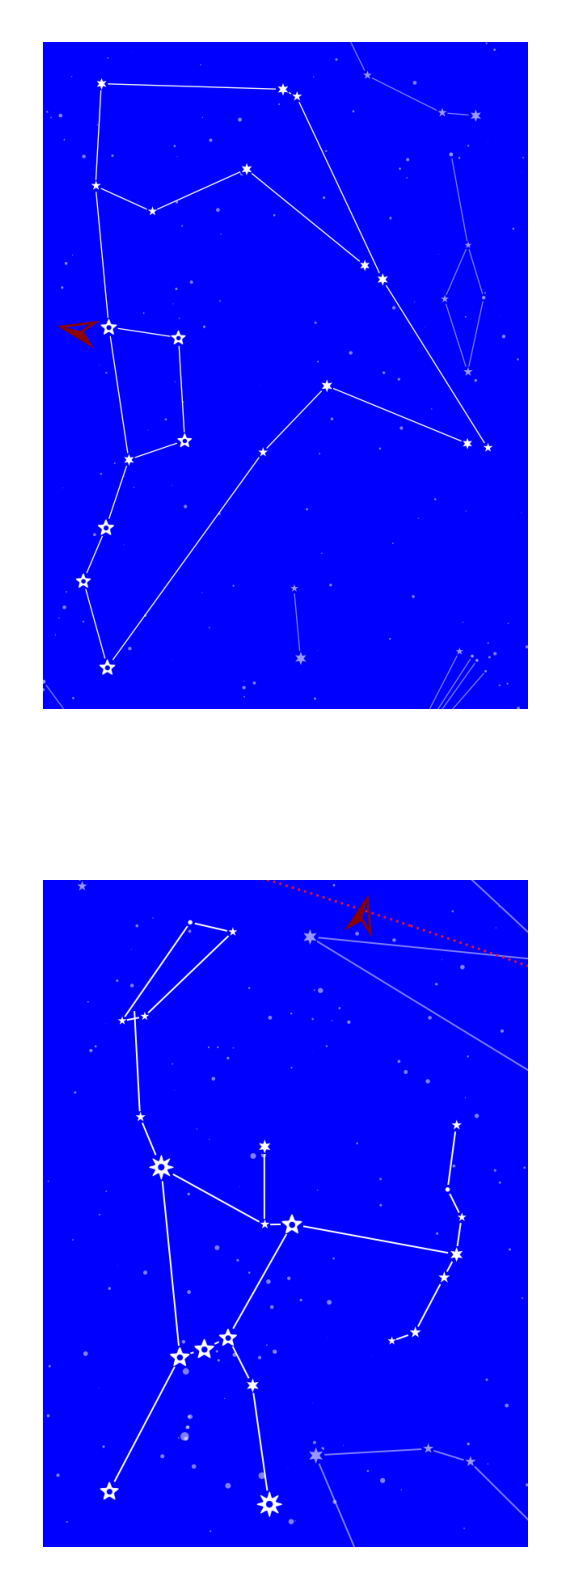

In [11]:
H, W = 6, 2
p = 0.05
r = 0.95


fig, ax = plt.subplots(figsize=(W, H), dpi=300)
fig.subplots_adjust()
ax.set_aspect('equal')
#ax.add_patch(Rectangle((0,0), W, H, facecolor='goldenrod'))

w = W - 2*p


ax.imshow(plt.imread(f'book/{IDS[0]}_lines.png'),  extent=(p, W-p, p, p+2.75/2*w), zorder=2)
ax.imshow(plt.imread(f'book/{IDS[1]}_lines.png'),  extent=(p, W-p, H-p-2.75/2*w, H-p), zorder=2)

 
ax.set_xlim(0,W)
ax.set_ylim(0,H)


ax.set_axis_off()

plt.savefig('bookmark.pdf', dpi = 300, transparent=True, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

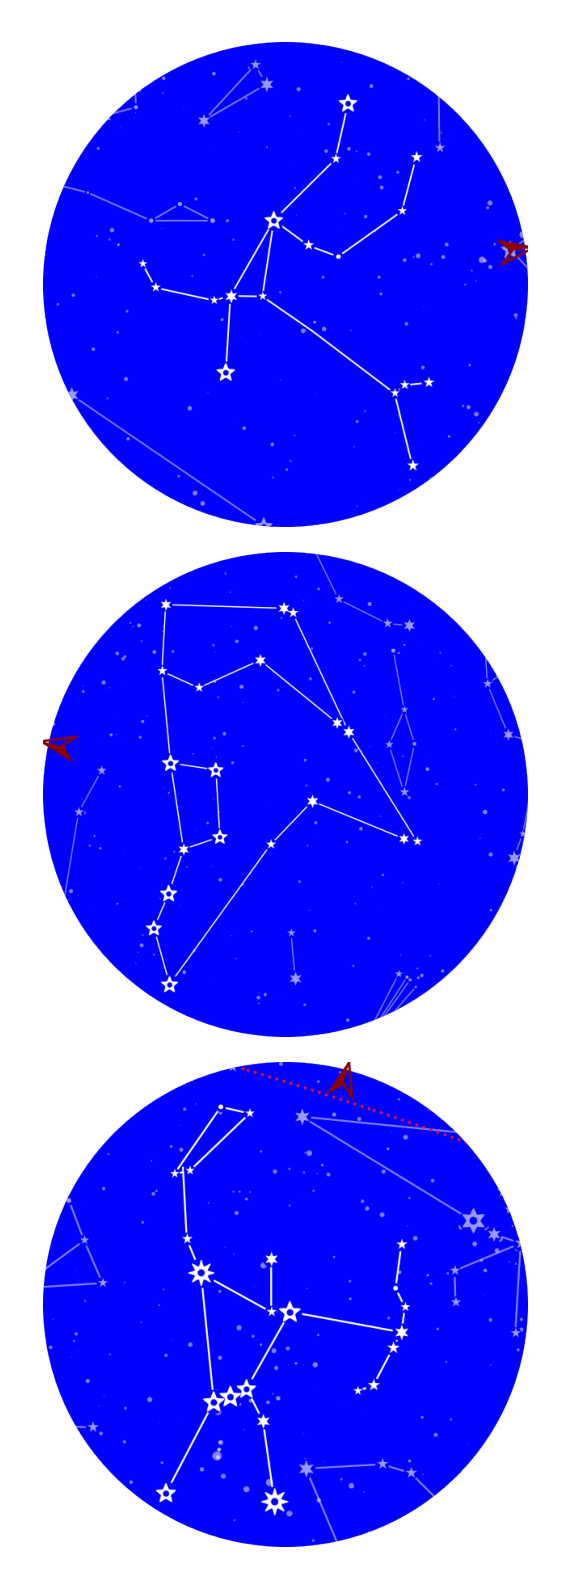

In [18]:
H, W = 6, 2
p = 0.05
r = 0.95


fig, ax = plt.subplots(figsize=(W, H), dpi=300)
fig.subplots_adjust()
ax.set_aspect('equal')
#ax.add_patch(Rectangle((0,0), W, H, facecolor='goldenrod'))

h = (H-2*r-2*p)/2

for i in range(3):
    x = p +r if i%2==0 else W-p-r
    y = p+r +  i*h
    ax.imshow(plt.imread(f'book/{IDS[i]}_lines.png'),  extent=(x-r, x+r, y-r, y+r), zorder=2)

 
ax.set_xlim(0,W)
ax.set_ylim(0,H)


ax.set_axis_off()

plt.savefig('bookmark.pdf', dpi = 300, transparent=True, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

In [13]:
# Create landscape PDF in inches
pdf = FPDF(orientation='L', unit='in', format='A4')

# Use page size from FPDF to avoid confusion
page_width = pdf.w    # 11.0 in (landscape)
page_height = pdf.h   # 8.5 in

box_width = 2
box_height = 7
boxes = 5
# Padding between and around boxes
pad_w = (page_width - boxes * box_width) / (boxes + 1)
pad_h = (page_height - box_height) / 2

# Font settings
font_size_pt = 10
pdf.set_font("Arial", size=font_size_pt)
# Text height in inches (1pt = 1/72 in)
text_height = font_size_pt / 72 + 0.01  # ~0.15 in
pdf.set_text_color(0, 255, 0)

pdf.set_auto_page_break(auto=False)

n_pages = (bookmarks + boxes - 1)//boxes

for i in range(n_pages):
    

    pdf.add_page()

    for i in range(boxes):
        x_box = pad_w * (i + 1) + box_width * i        
        
        # Divider lines and text
        for j, id in enumerate(ids_page[i]):
            y_box = pad_h + box_height / 3 * j
            pdf.ellipse()
            line_y = y_box + box_height/3

            # Divider line
            pdf.line(x_box, line_y, x_box + box_width, line_y)

            # Text placed just above the line
            text_y = line_y - text_height - 0.02  # buffer from line
            if text_y < y_box:
                text_y = y_box + 0.02  # clamp to top of box

            pdf.set_xy(x_box, text_y)
            pdf.cell(w=box_width, h=text_height, txt=harey.names[id], border=0, align='C')


    pdf.add_page()

    for i in range(boxes):
        x_box = pad_w * (boxes - i) + box_width * (boxes - i - 1)       
        
        # Divider lines and text
        for j, id in enumerate(ids_page[i]):
            y_box = pad_h + box_height / 3 * j
            pdf.image(f'book/{id}_bare.png', x_box, y_box, box_width, box_height/3)
            line_y = y_box + box_height/3

            # Divider line
            pdf.line(x_box, line_y, x_box + box_width, line_y)

            # Text placed just above the line
            text_y = line_y - text_height - 0.02  # buffer from line
            if text_y < y_box:
                text_y = y_box + 0.02  # clamp to top of box

            pdf.set_xy(x_box, text_y)
            pdf.cell(w=box_width, h=text_height, txt=harey.names[id], border=0, align='C')


/tmp/ipykernel_10851/1867131548.py:17: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=font_size_pt)


TypeError: FPDF.ellipse() missing 4 required positional arguments: 'x', 'y', 'w', and 'h'